In [17]:
from pathlib import Path
import sys

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

sys.path.insert(0, str(Path.cwd().parent))

from utils.fancy_barplot import fancy_bars
from utils.fancy_hist import fancy_hist
from utils.triple_plot import normality_report

In [3]:
data_path = Path("../data")
labels_path = data_path / Path("labels/LUNA25_Public_Training_Development_Data.csv")

In [4]:
df = pd.read_csv(labels_path)
df.head()

,PatientID,SeriesInstanceUID,StudyDate,CoordX,CoordY,CoordZ,LesionID,AnnotationID,NoduleID,label,Age_at_StudyDate,Gender
0,100570,1.2.840.113654.2.55.32380467633296345717423514...,19990102,61.14,-163.28,-177.75,1,100570_1_19990102,100570_1,1,63,Male
1,106364,1.2.840.113654.2.55.16930993607533226779708566...,19990102,30.64,-95.96,-128.59,1,106364_1_19990102,106364_1,1,67,Female
2,127302,1.2.840.113654.2.55.13728437630416839550344528...,20000102,-82.53,-27.85,-209.46,1,127302_1_20000102,127302_1,1,61,Male
3,128899,1.2.840.113654.2.55.40415300708683206534849072...,20010102,-38.69,-8.78,-39.43,1,128899_1_20010102,128899_1,1,64,Male
4,215816,1.3.6.1.4.1.14519.5.2.1.7009.9004.241362276021...,19990102,32.89,-37.98,-100.04,1,215816_1_19990102,215816_1,1,69,Female


# Examinar variable objetivo

<Axes: title={'left': 'Distribución variable objetivo'}, xlabel='Label', ylabel='Porcentaje'>

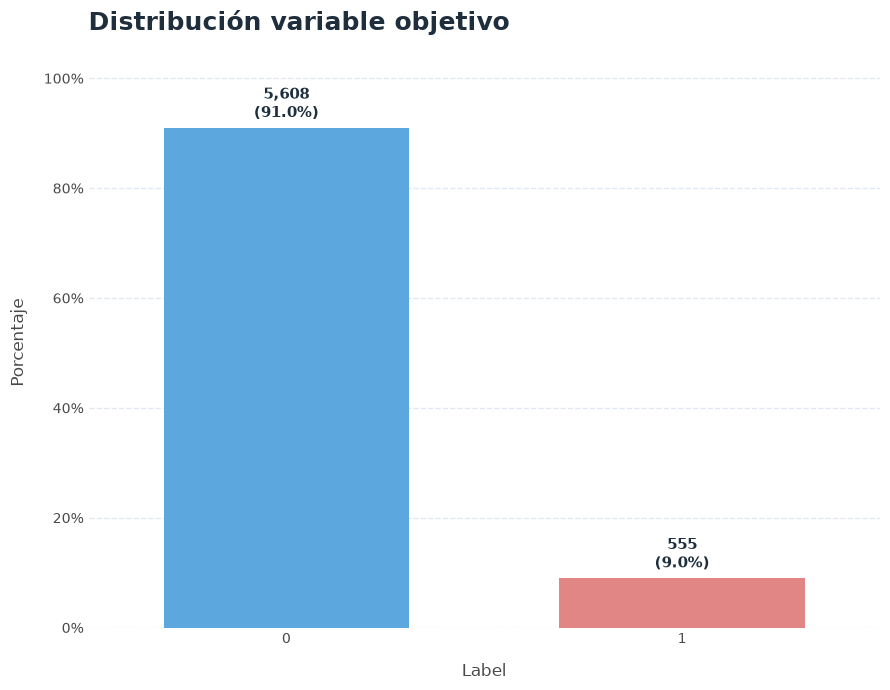

In [5]:
fancy_bars(
    df,
    'label',
    pct=True,
    labels='both',
    title='Distribución variable objetivo'
    )

## Generalidades del set cualitativo y la metadata

### ¿Cuántos registros existen?

In [6]:
df.shape

(6163, 12)

Hay 6163 nodulos registrados, en etapas posteriores se validara cuantos nodulos hay en los zip de LUNA25

### ¿Qué tipo de variables contiene?

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6163 entries, 0 to 6162
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   PatientID          6163 non-null   int64  
 1   SeriesInstanceUID  6163 non-null   str    
 2   StudyDate          6163 non-null   int64  
 3   CoordX             6163 non-null   float64
 4   CoordY             6163 non-null   float64
 5   CoordZ             6163 non-null   float64
 6   LesionID           6163 non-null   int64  
 7   AnnotationID       6163 non-null   str    
 8   NoduleID           6163 non-null   str    
 9   label              6163 non-null   int64  
 10  Age_at_StudyDate   6163 non-null   int64  
 11  Gender             6163 non-null   str    
dtypes: float64(3), int64(5), str(4)
memory usage: 577.9 KB


<Axes: title={'left': 'Distribución género'}, xlabel='Gender', ylabel='Porcentaje'>

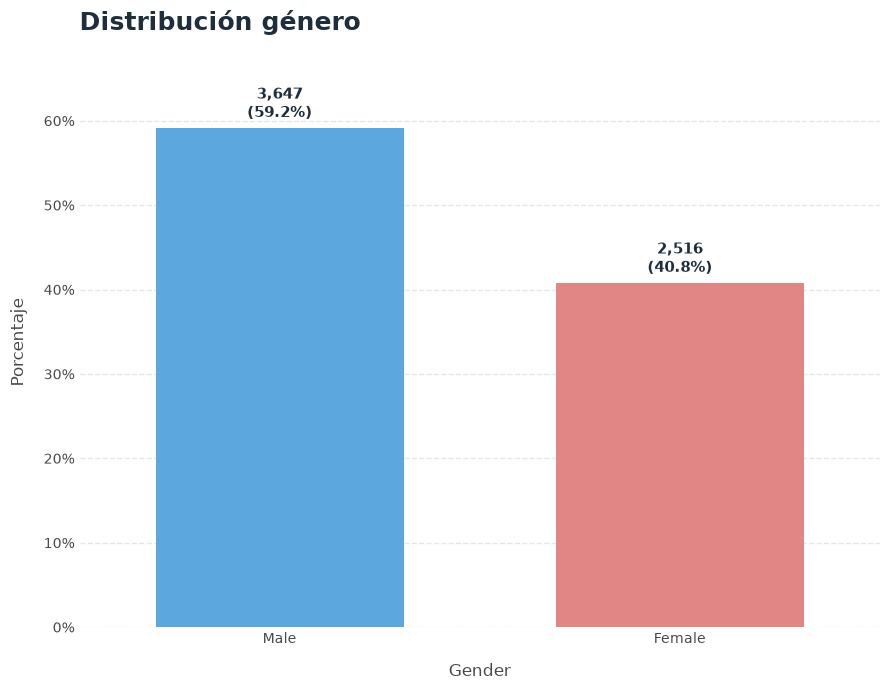

In [8]:
fancy_bars(
    df,
    'Gender',
    pct=True,
    labels='both',
    title='Distribución género'
    )

<Axes: title={'left': 'Distribución edad'}, xlabel='Conteo', ylabel='Age At Studydate'>

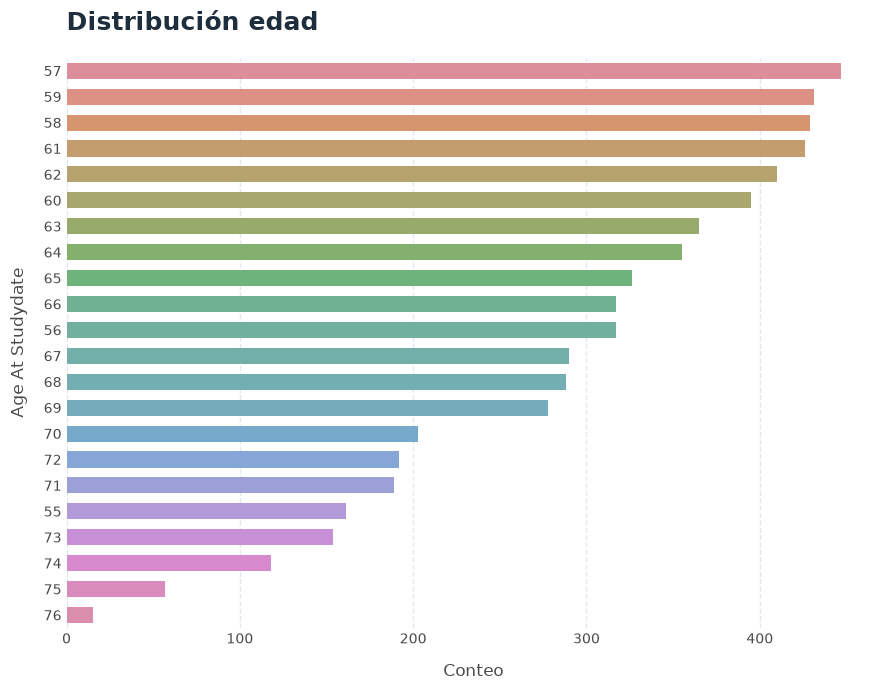

In [9]:
fancy_bars(
    df,
    'Age_at_StudyDate',
    title='Distribución edad',
    orient='h'
)

<Axes: title={'left': 'Distribución edad'}, xlabel='Age At Studydate', ylabel='Conteo'>

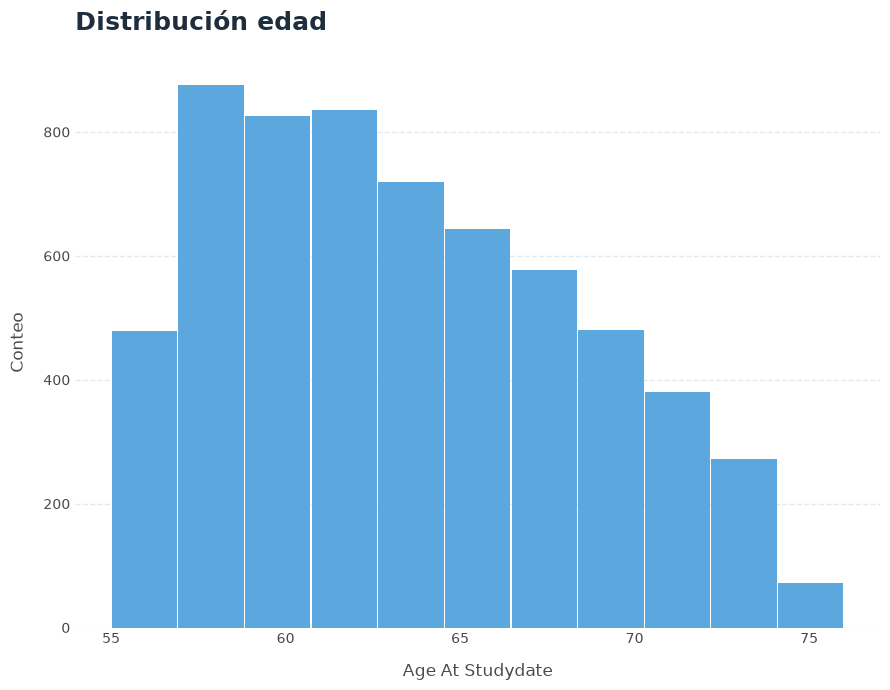

In [ ]:
fancy_hist(
    df,
    'Age_at_StudyDate',
    n_bins=11,
    title='Distribución edad'
    )

In [11]:
df['Age_at_StudyDate'].unique()

array([63, 67, 61, 64, 69, 60, 65, 66, 58, 59, 74, 68, 70, 56, 57, 72, 73,
       55, 71, 62, 75, 76])

## Diagnostico Calidad

In [12]:
df.isnull().sum()

PatientID            0
SeriesInstanceUID    0
StudyDate            0
CoordX               0
CoordY               0
CoordZ               0
LesionID             0
AnnotationID         0
NoduleID             0
label                0
Age_at_StudyDate     0
Gender               0
dtype: int64

In [13]:
df.duplicated().sum()

np.int64(0)

findfont: Failed to find font weight medium, now using 400.


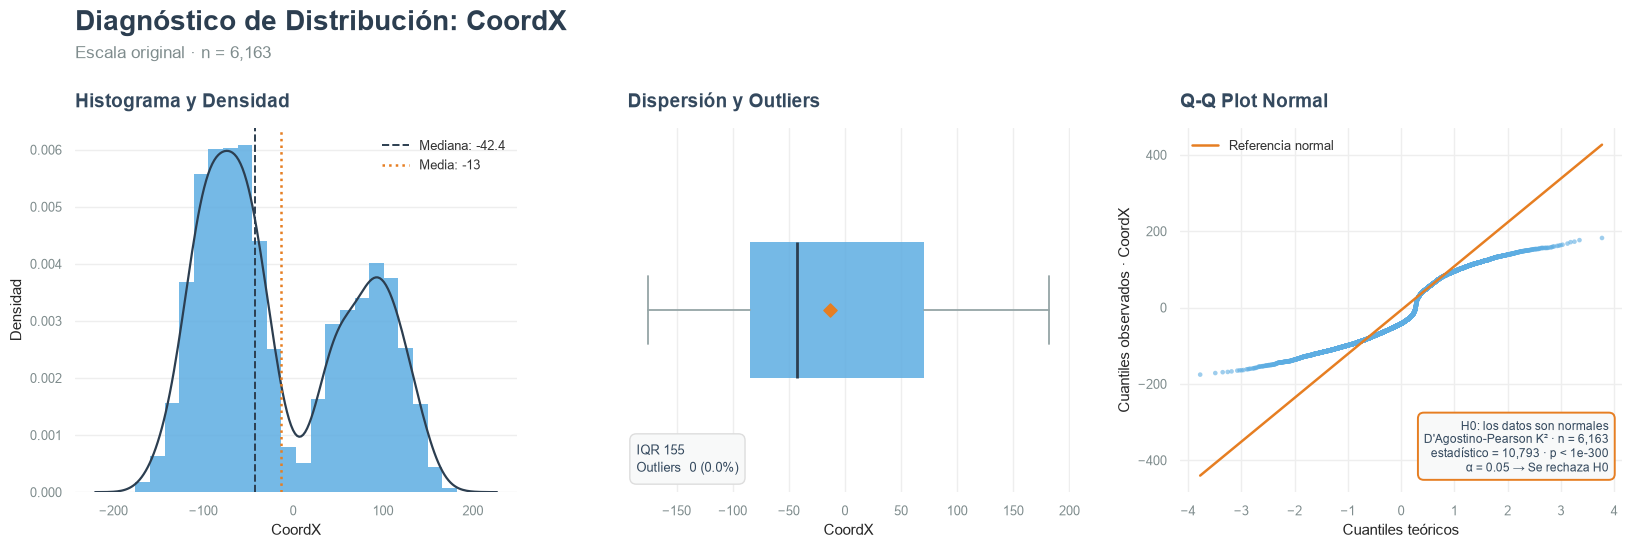

In [14]:
cordx_resume = normality_report(df, 'CoordX')

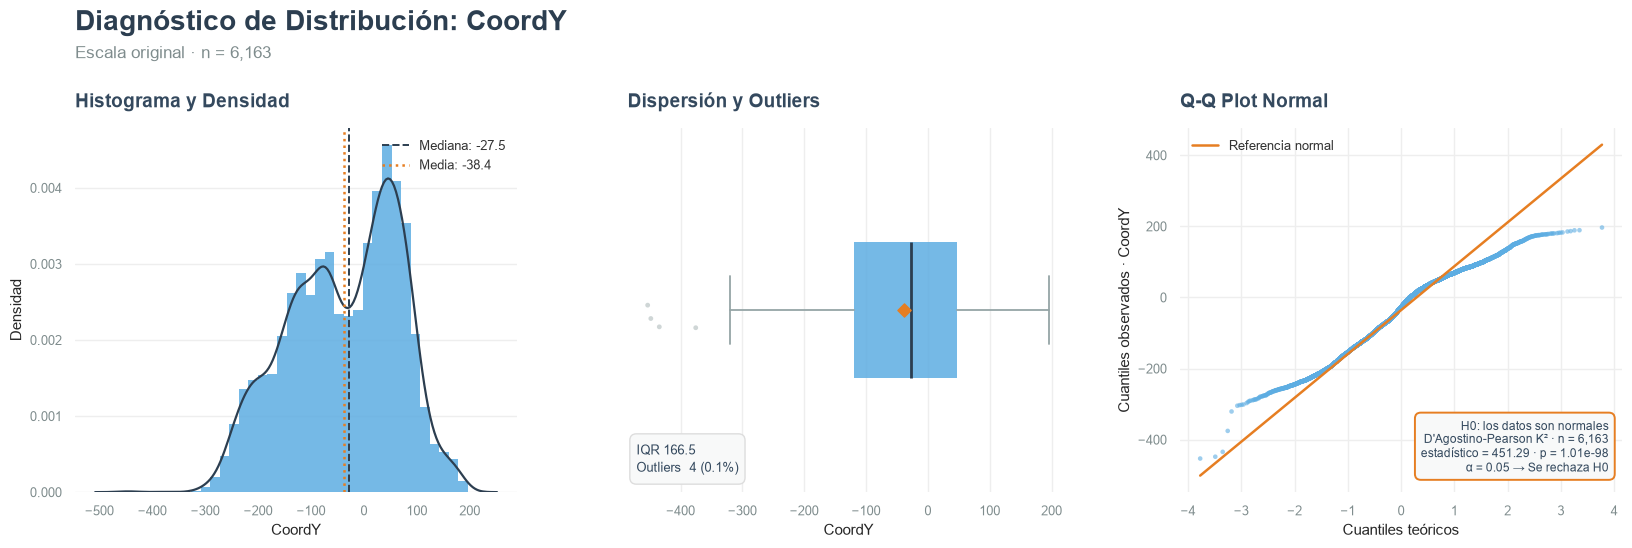

In [15]:
cordy_resume = normality_report(df, 'CoordY')

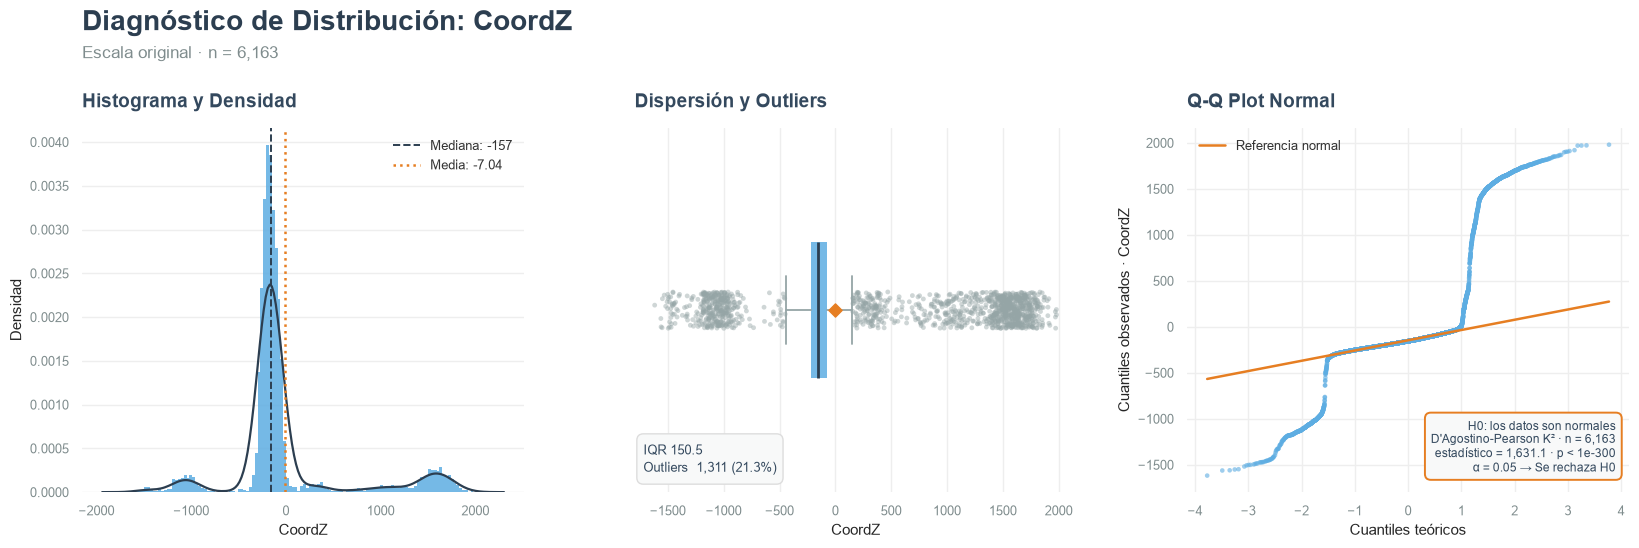

In [16]:
cordz_resume = normality_report(df, 'CoordZ')

## Explore metadata

In [30]:
# Definición de estructuras de rutas
EXTRACTED_DIR = data_path / "images/extracted/luna25_nodule_blocks"
NODULE_IMAGES_DIR = EXTRACTED_DIR / "image"
NODULE_METADATA_DIR = EXTRACTED_DIR / "metadata"
NODULE_MASKS_DIR = EXTRACTED_DIR / "mask"  # Si aplica para tus segmentaciones

# Función generadora de rutas por ID
def get_block_path(file_id: str, subfolder: str = "image") -> Path:
    """Devuelve la ruta al archivo .npy dado su identificador."""
    filename = file_id if file_id.endswith(".npy") else f"{file_id}.npy"
    return EXTRACTED_DIR / subfolder / filename

(64, 128, 128) int16
-1024 1870


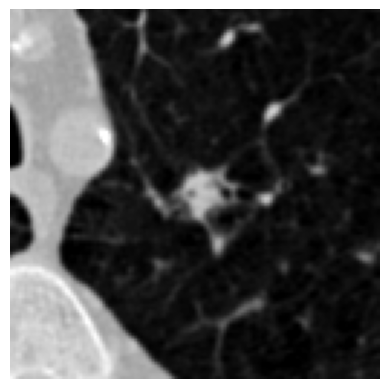

In [31]:
# Carga directa utilizando la ruta modular
block = np.load(get_block_path("218698_3_20010102"))

print(block.shape, block.dtype)          # (64, 128, 128)
print(block.min(), block.max())          # HU crudas, aprox -1024 a +1000
#print(meta["spacing"])                   # (z, y, x) en mm

z = block.shape[0] // 2                  # el nódulo está en el centro
plt.imshow(block[z], cmap="gray", vmin=-1000, vmax=400)
plt.axis("off")
plt.show()

In [32]:
filas = []
for ruta in sorted(NODULE_METADATA_DIR.glob("*.npy")):
    m = np.load(ruta, allow_pickle=True).item()

    spacing   = np.asarray(m["spacing"], dtype=float)    # (z, y, x) en mm
    origin    = np.asarray(m["origin"], dtype=float)     # (z, y, x) en mm
    transform = np.asarray(m["transform"], dtype=float)  # 3x3

    filas.append({
        "AnnotationID": ruta.stem,
        "spacing_z": spacing[0],
        "spacing_y": spacing[1],
        "spacing_x": spacing[2],
        "anisotropia": spacing[0] / spacing[1],
        "origin_z": origin[0],
        "origin_y": origin[1],
        "origin_x": origin[2],
        "transform_identidad": np.allclose(transform, np.eye(3)),
    })

meta = pd.DataFrame(filas)

print(f"anotaciones: {len(meta)}")
print(f"claves del dict: {list(m.keys())}")
print(f"transform no identidad: {(~meta.transform_identidad).sum()}")
print()
print(meta[["spacing_z", "spacing_y", "spacing_x", "anisotropia"]].describe())

meta.head()

anotaciones: 6163
claves del dict: ['origin', 'spacing', 'transform']
transform no identidad: 3

         spacing_z    spacing_y    spacing_x  anisotropia
count  6163.000000  6163.000000  6163.000000  6163.000000
mean      1.948570     0.661145     0.661145     2.979692
std       0.415588     0.069552     0.069552     0.709682
min       0.500000     0.460938     0.460938     0.853333
25%       1.800000     0.609375     0.609375     2.633143
50%       2.000000     0.664062     0.664062     2.994152
75%       2.000000     0.703125     0.703125     3.447812
max       3.200001     0.976562     0.976562     6.277396


,AnnotationID,spacing_z,spacing_y,spacing_x,anisotropia,origin_z,origin_y,origin_x,transform_identidad
0,100012_1_19990102,2.0,0.585938,0.585938,3.413333,-154.399994,-173.808594,-70.605469,True
1,100012_1_20000102,2.0,0.546875,0.546875,3.657143,1158.699951,-165.351562,-82.867188,True
2,100035_1_19990102,2.5,0.585938,0.585938,4.266663,-272.500000,-31.713974,87.389259,True
3,100035_1_20000102,2.5,0.585938,0.585938,4.266663,-263.450012,-40.429600,90.075188,True
4,100035_1_20010102,2.5,0.585938,0.585938,4.266663,-291.859985,-17.651463,94.518944,True


In [33]:
num_files = sum(1 for item in NODULE_IMAGES_DIR.iterdir() if item.is_file())

print(f"Total de archivos: {num_files}")

Total de archivos: 6163
